In [43]:
from runner_experiments import conformal_metrics_from_pvalues, output_dir
import pandas as pd
import numpy as np

for dataset, bestmodel, alpha in zip(['sepsis_cases', 'hospital_billing', 'FMP'], ['DT', 'XGBoost', 'DT'], [0.06,0.06,0.16]):
    #print(dataset, bestmodel, alpha)
    if dataset == 'FMP':
        df = pd.read_csv(output_dir+'/C_DT_predictions.csv', sep=';')
        true_labels = df['true_labels'].values
        p_values = df.drop(columns=['true_labels']).values
        cov, size, prec, rec, f1 = conformal_metrics_from_pvalues(
                p_values, true_labels, alpha, class_labels=("noAdapt", "Adapt")
            )
        print(f"Coverage: {cov:.3f}")
        print(f"Avg set size: {size:.3f} ")
        print(f"F1 (Adapt): {f1:.3f}")

    else:
        dfs = []
        covs=[]
        f1s=[]
        sizes=[]
        for fold in range(1):
            path = f"{output_dir}/output{dataset}_p_values{bestmodel}_predictions_fold{fold+1}.csv"
            dfs.append(pd.read_csv(path, sep=';'))
            true_labels = dfs[fold]['true_labels'].values
            p_values = dfs[fold].drop(columns=['true_labels']).values
            cov, size, prec, rec, f1 = conformal_metrics_from_pvalues(
                p_values, true_labels, alpha, class_labels=("noAdapt", "Adapt")
            )
            covs.append(cov)
            f1s.append(f1)
            sizes.append(size)
            print(f"Coverage: {np.mean(covs):.3f} std {np.std(covs):.3f}")
            print(f"Avg set size: {np.mean(sizes):.3f} std {np.std(sizes):.3f}")
            #print(f"Precision (Adapt): {prec:.3f}")
            #print(f"Recall (Adapt): {rec:.3f}")
            print(f"F1 (Adapt): {np.mean(f1s):.3f} std {np.std(f1s):.3f}")

Coverage: 0.941 std 0.000
Avg set size: 0.994 std 0.000
F1 (Adapt): 0.964 std 0.000
Coverage: 0.950 std 0.000
Avg set size: 0.989 std 0.000
F1 (Adapt): 0.764 std 0.000
Coverage: 0.900
Avg set size: 0.971 
F1 (Adapt): 0.852


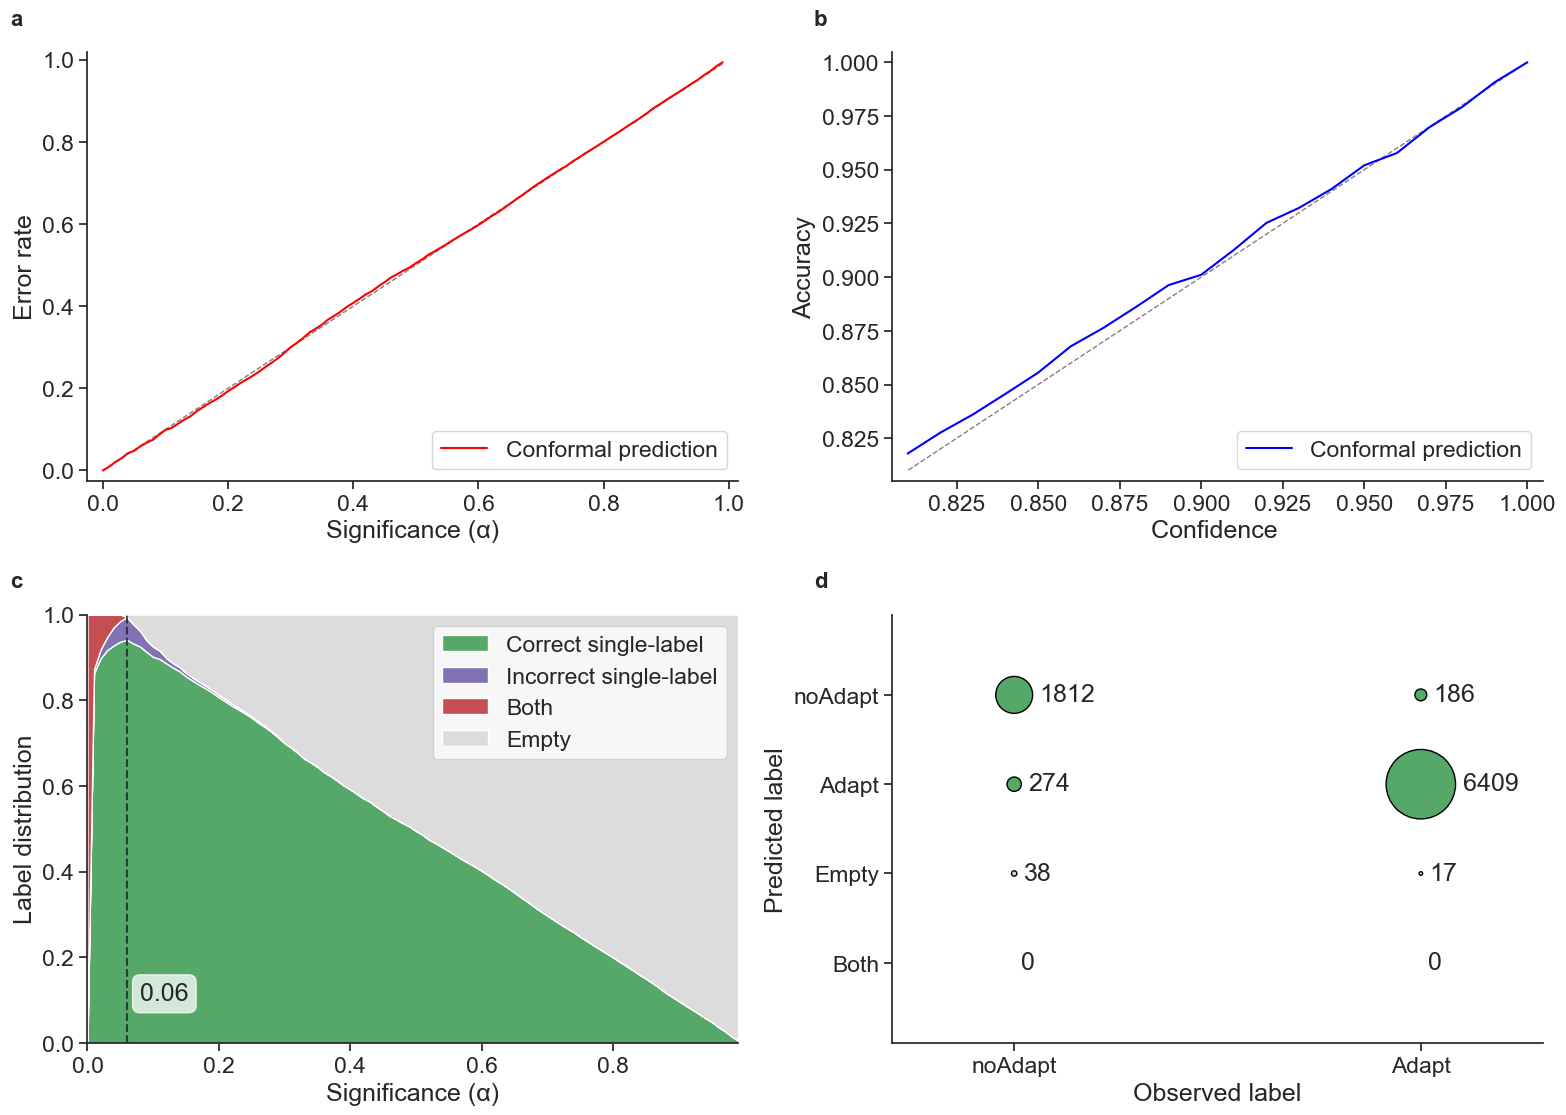

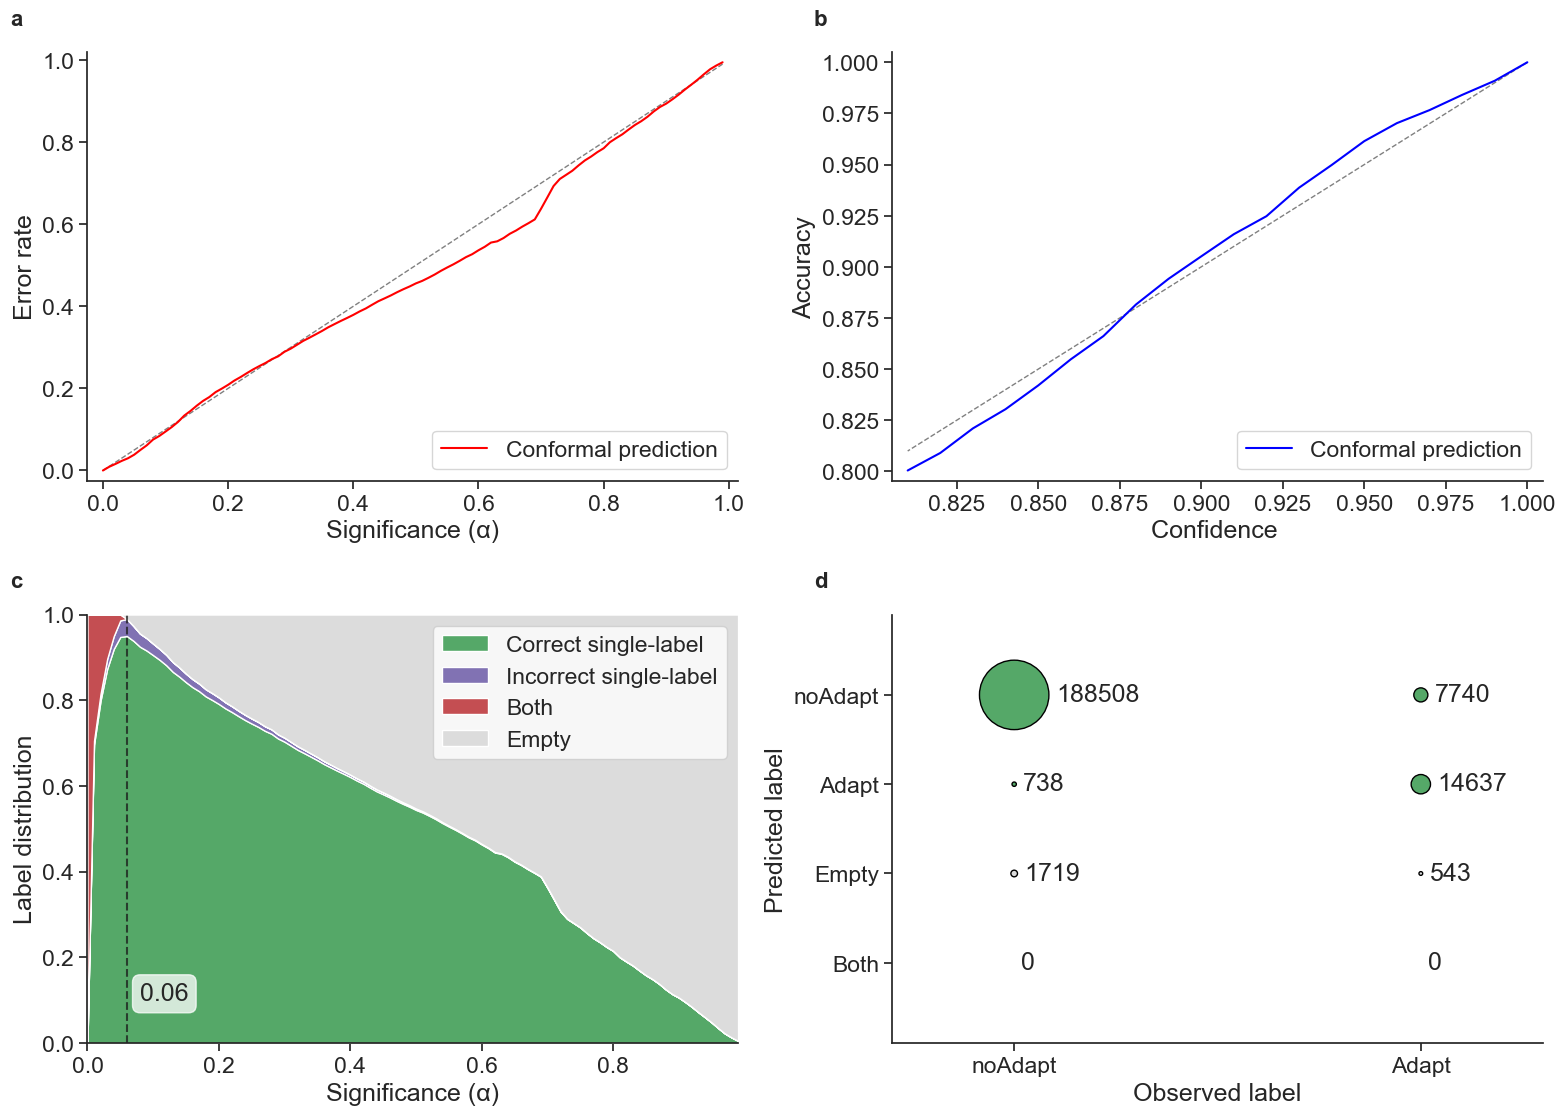

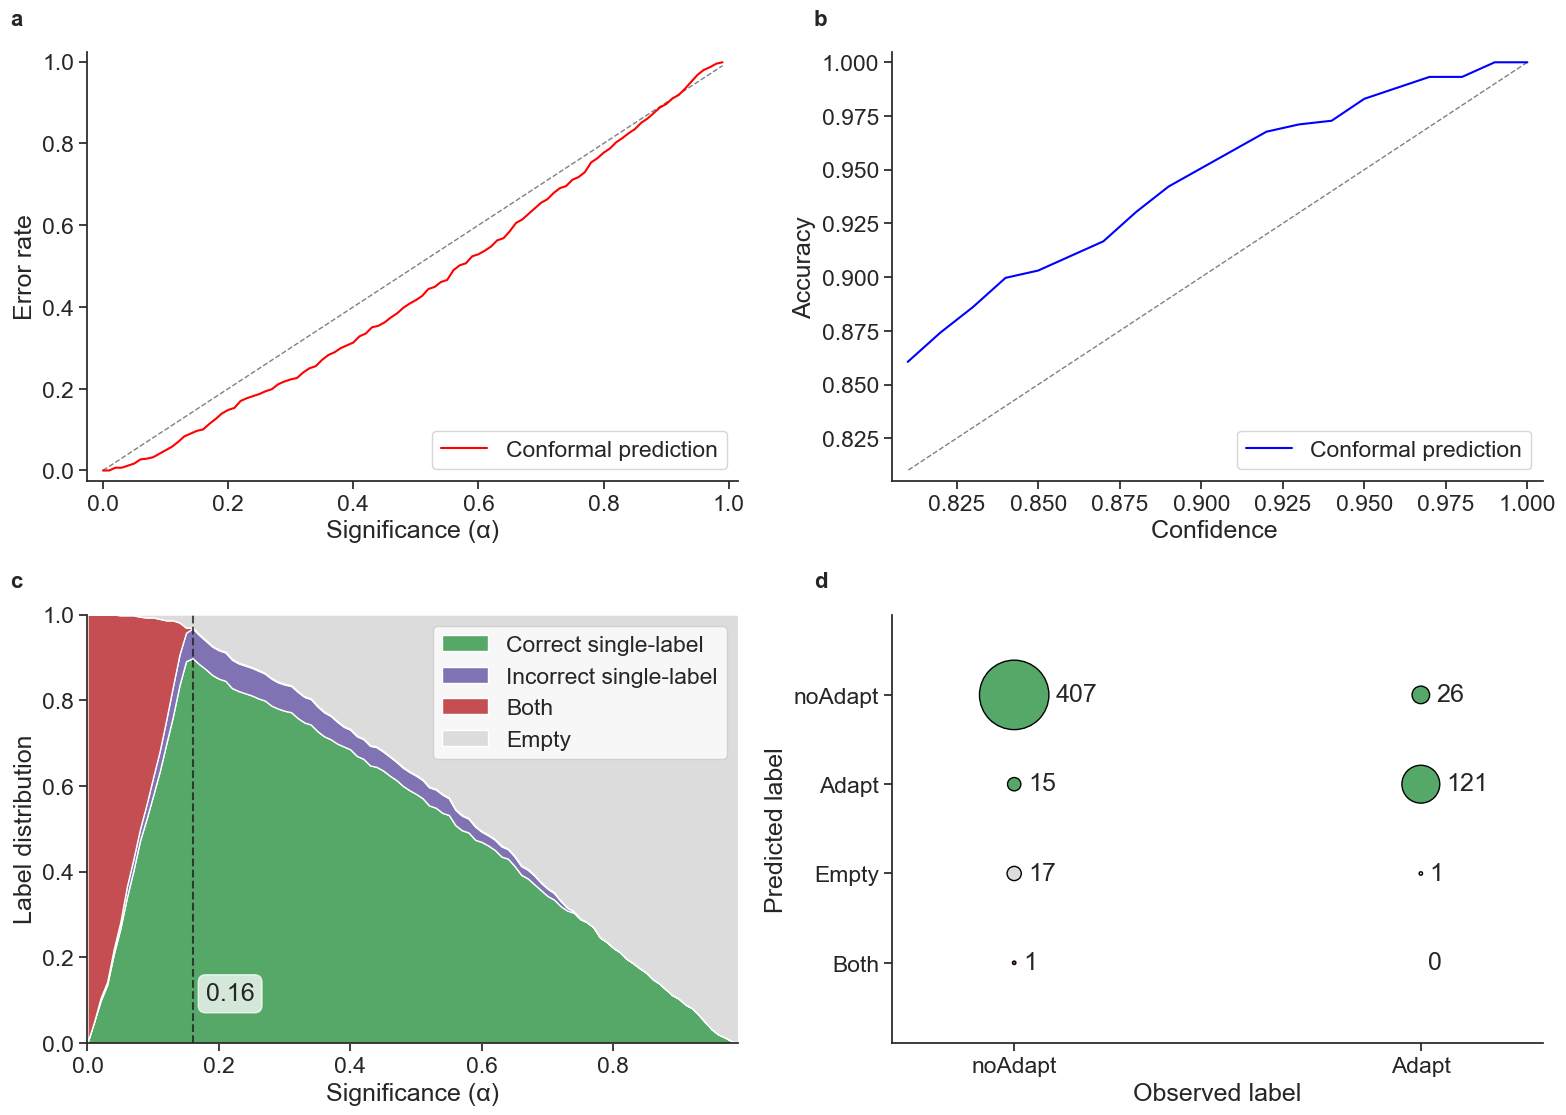

In [74]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("plot_utils/python/src/")
from plot_utils.python.src.pharmbio.cp import metrics
from plot_utils.python.src.pharmbio.cp import plotting

# Set a different style and context
plotting.update_plot_settings(context='talk', font_scale=1.5)
for dataset, bestmodel, alpha in zip(['sepsis_cases', 'hospital_billing', 'FMP'], ['DT', 'XGBoost', 'DT'], [0.06,0.06,0.16]):
    #print(dataset, bestmodel, alpha)
    if dataset == 'FMP': df = pd.read_csv(output_dir+'/C_DT_predictions.csv', sep=';')
    else:
        dfs = []
        covs=[]
        f1s=[]
        sizes=[]
        for fold in range(3):
            path = f"{output_dir}/output{dataset}_p_values{bestmodel}_predictions_fold{fold+1}.csv"
            dfs.append(pd.read_csv(path, sep=';'))
        df = pd.concat(dfs, ignore_index=True)

    true_labels = df['true_labels'].values
    p_values = df.drop(columns=['true_labels']).values


    fig, axes = plt.subplots(2,2, figsize=(16,12))
    class_labels=['noAdapt','Adapt']


    # Calibration plot
    plotting.plot_calibration_clf(true_labels, p_values,cm = ['red','blue'], ax=axes[0,0],plot_all_labels=False, labels=class_labels,overall_color='red')
    axes[0, 0].text(-0.1, 1.1, 'a', transform=axes[0, 0].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

    plotting.plot_calibration_clf(true_labels, p_values,labels=class_labels,
                                  sign_vals=np.arange(0.0,.2,0.01),overall_color='blue',
                                  cm = ['red','blue'], ax=axes[0,1],
                                  plot_all_labels=False, flip_x=True, # confidence instead of significance on x-axis
                                  flip_y=True, # accuracy instead of error rate on y-axis
                                  )
    #axes[0, 1].set_title('Calibration plot confidence vs accuracy', fontsize=16)
    axes[0, 1].text(-0.1, 1.1, 'b', transform=axes[0, 1].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

    plotting.plot_label_distribution(y_true=true_labels,p_values=p_values, ax=axes[1,0], display_incorrect=True)
    #axes[1, 0].set_title('Label distribution', fontsize=16)
    axes[1, 0].text(-0.1, 1.1, 'c', transform=axes[1, 0].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

    plotting.plot_confusion_matrix_bubbles(metrics.confusion_matrix(true_labels,p_values, alpha, labels=class_labels), ax=axes[1,1])
    #axes[1, 1].set_title('Confusion matrix (sign=0.2)', fontsize=16)
    axes[1, 1].text(-0.1, 1.1, 'd', transform=axes[1, 1].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f"{output_dir}/{dataset}_calibration_efficiency_plots.pdf")

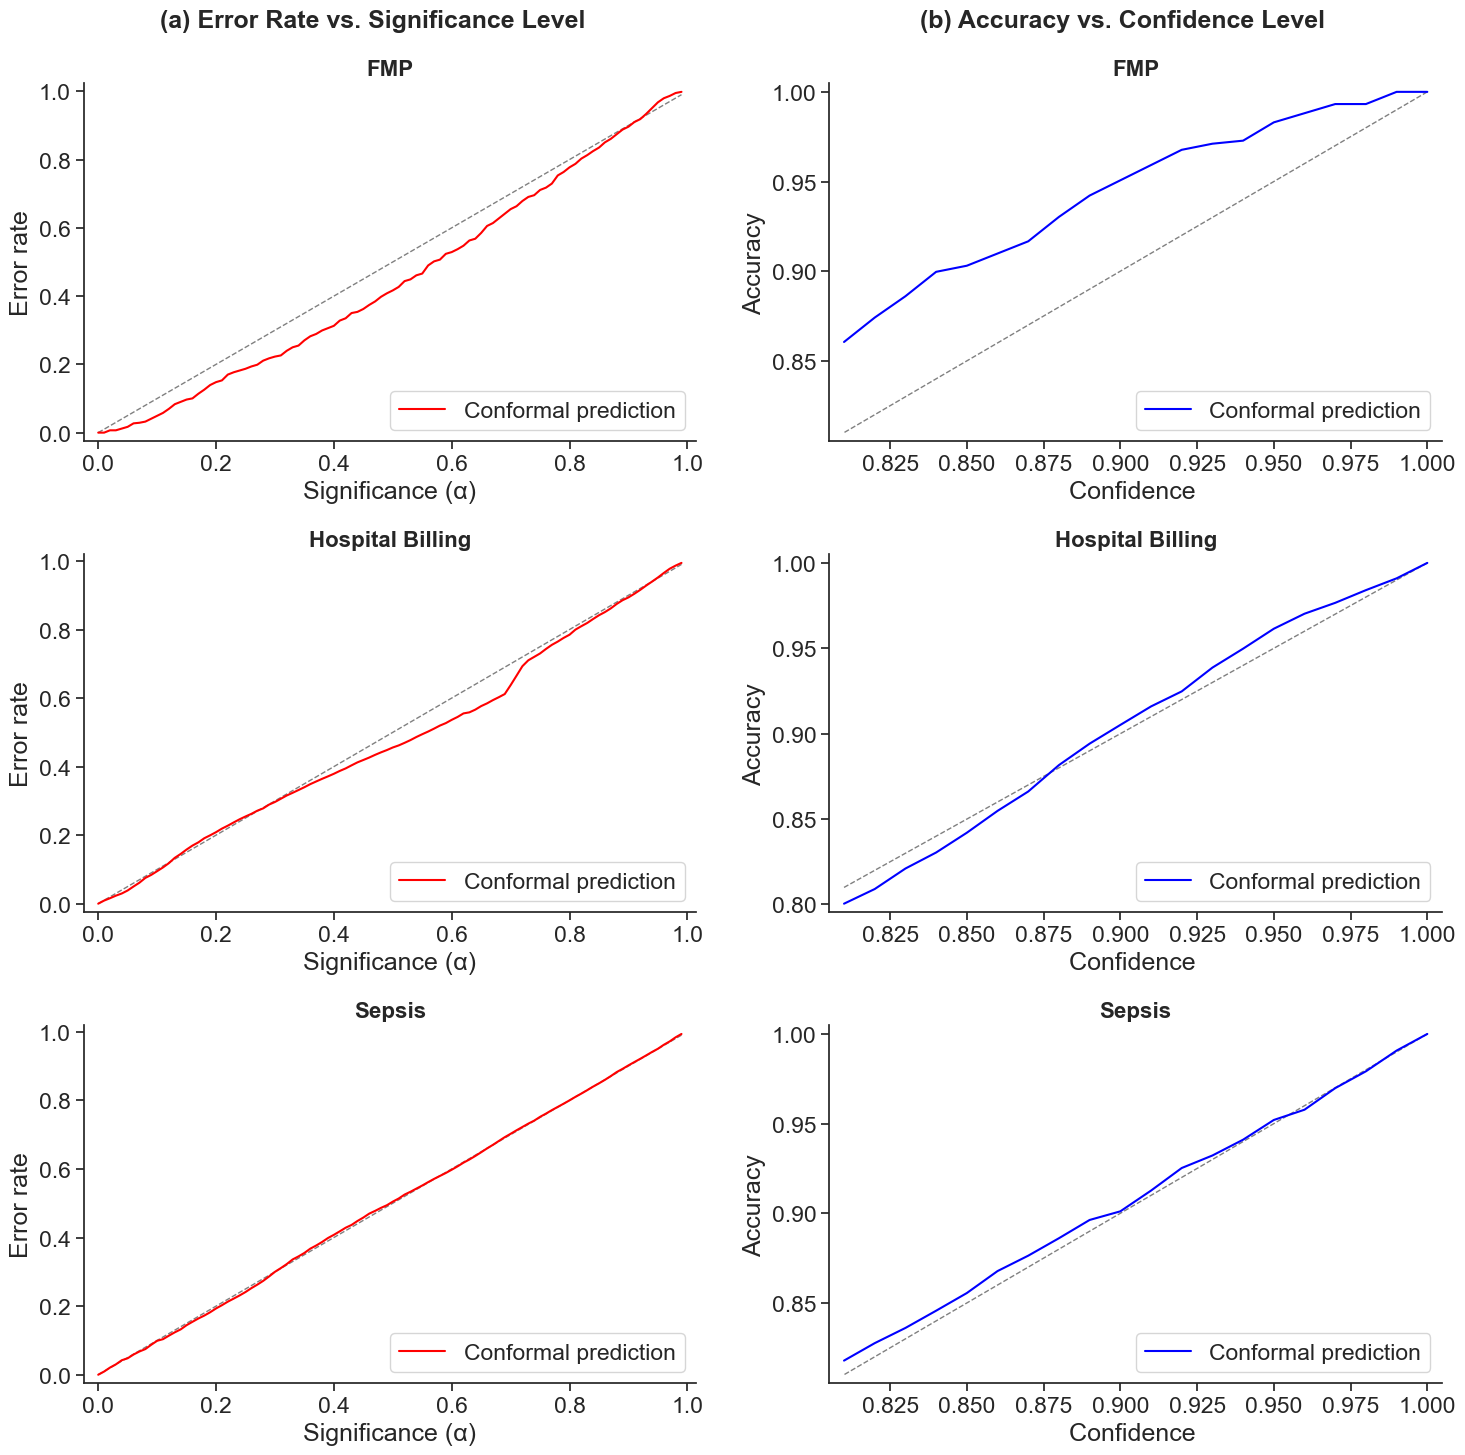

In [77]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("plot_utils/python/src/")
from plot_utils.python.src.pharmbio.cp import plotting

# Set a different style and context
plotting.update_plot_settings(context='talk', font_scale=1.5)

# Create 3x2 grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# Dataset configuration
datasets = ['FMP', 'hospital_billing','sepsis_cases']
bestmodels = ['DT', 'XGBoost', 'DT']
class_labels = ['noAdapt', 'Adapt']

for row, dataset, bestmodel in zip(range(3), datasets, bestmodels):

    if dataset == 'FMP':
        df = pd.read_csv(f"{output_dir}/C_DT_predictions.csv", sep=';')
    else:
        dfs = []  # Initialize list before collecting folds
        for fold in range(3):
            path = f"{output_dir}/output{dataset}_p_values{bestmodel}_predictions_fold{fold+1}.csv"
            dfs.append(pd.read_csv(path, sep=';'))
        df = pd.concat(dfs, ignore_index=True)
        dataset="Sepsis" if dataset == 'sepsis_cases' else "Hospital Billing"

    true_labels = df['true_labels'].values
    p_values = df.drop(columns=['true_labels']).values
    x= 0.12 if dataset != "Hospital Billing" else 0.27

    # Calibration plot
    plotting.plot_calibration_clf(true_labels, p_values,cm = ['red','blue'], ax=axes[row,0],plot_all_labels=False, labels=class_labels,overall_color='red')
    axes[row, 0].set_title(dataset, fontsize=16,fontweight='bold')
    axes[row, 0].text(x, 1.1, '', transform=axes[row, 0].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

    plotting.plot_calibration_clf(true_labels, p_values,labels=class_labels,
                                  sign_vals=np.arange(0.0,.2,0.01),overall_color='blue',
                                  cm = ['red','blue'], ax=axes[row,1],
                                  plot_all_labels=False, flip_x=True, # confidence instead of significance on x-axis
                                  flip_y=True, # accuracy instead of error rate on y-axis
                                  )
    axes[row, 1].text(x, 1.1, '', transform=axes[row, 1].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
    axes[row,1 ].set_title(dataset, fontsize=16,fontweight='bold')

fig.text(0.26, 0.96, '(a) Error Rate vs. Significance Level', ha='center', va='bottom', fontsize=18, fontweight='bold')
fig.text(0.76, 0.96, '(b) Accuracy vs. Confidence Level', ha='center', va='bottom', fontsize=18, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f"{output_dir}/calibration_plots.pdf")

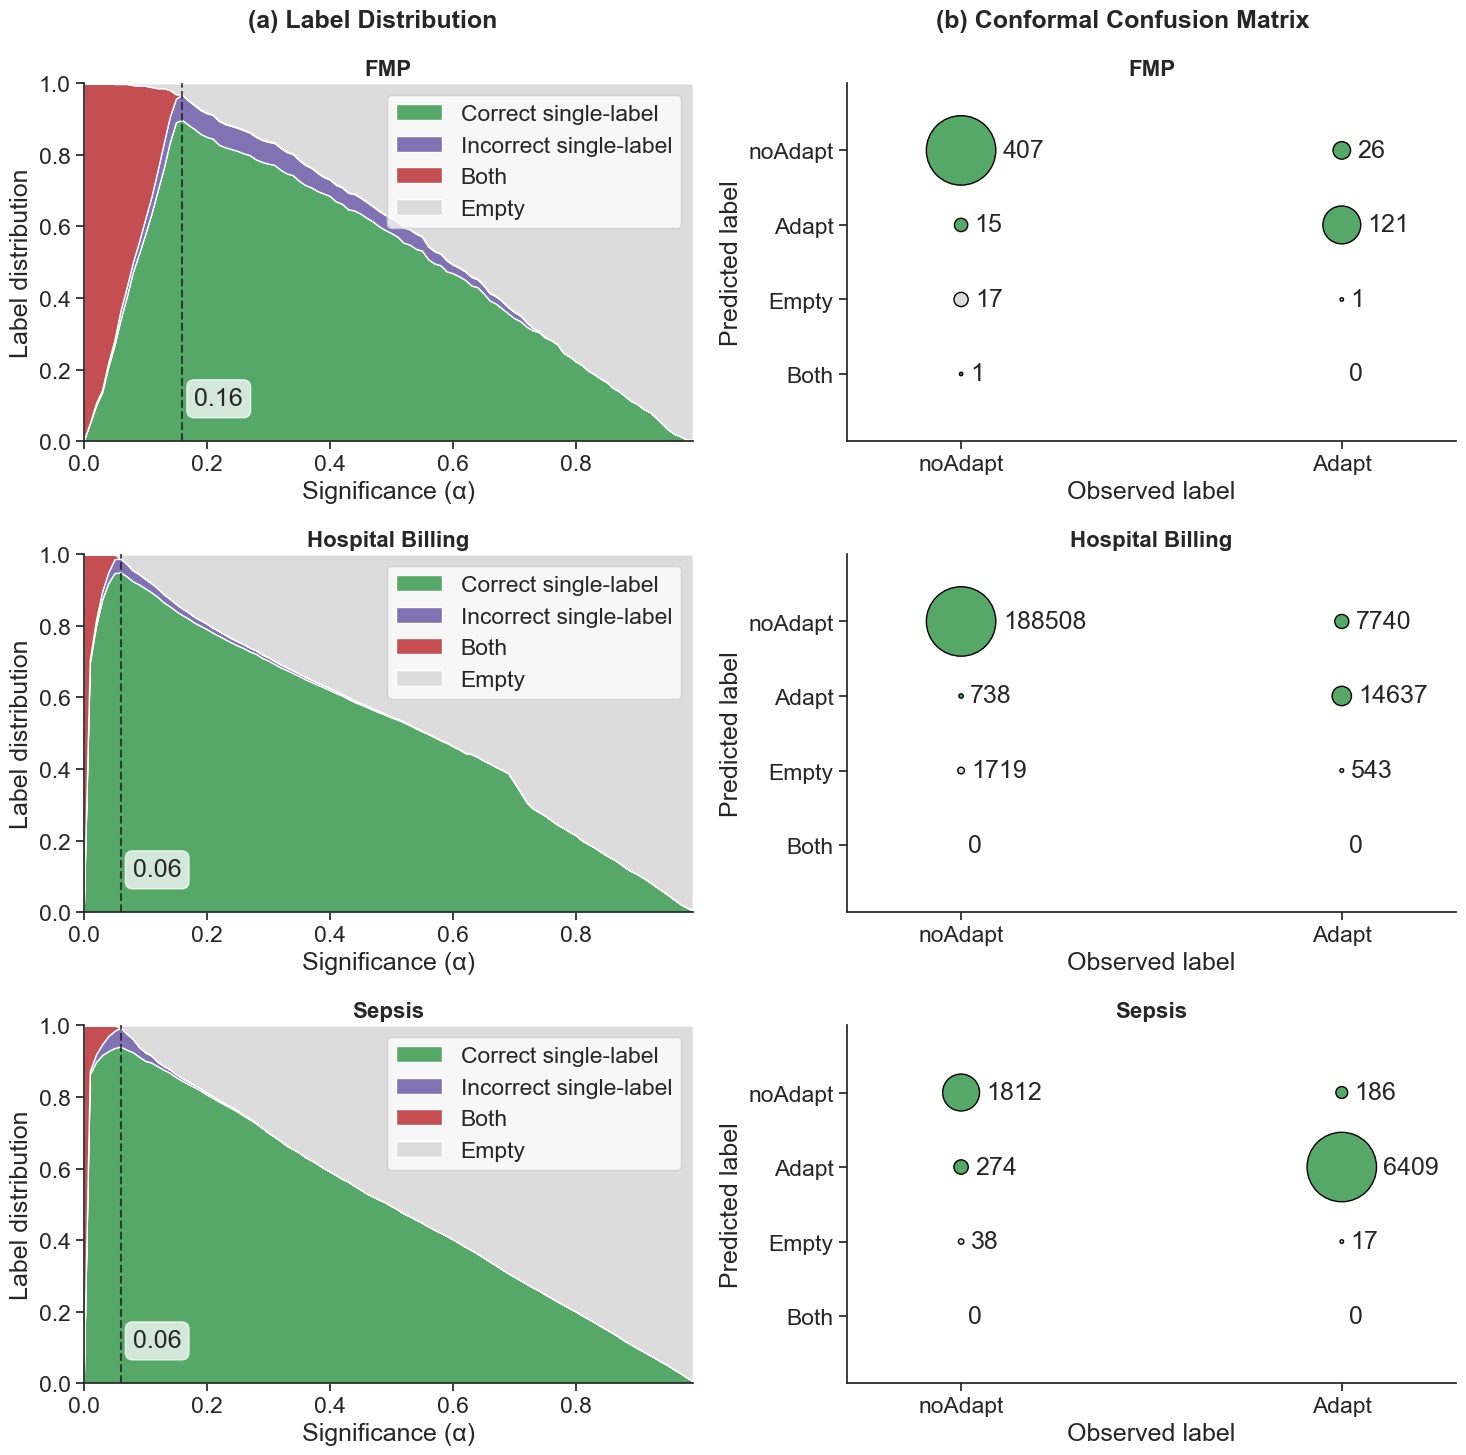

In [78]:
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("plot_utils/python/src/")
from plot_utils.python.src.pharmbio.cp import metrics
from plot_utils.python.src.pharmbio.cp import plotting

# Set a different style and context
plotting.update_plot_settings(context='talk', font_scale=1.5)

# Create 3x2 grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# Dataset configuration
datasets = ['FMP', 'hospital_billing','sepsis_cases']
bestmodels = ['DT', 'XGBoost', 'DT']
alphas = [ 0.16, 0.06, 0.06]
class_labels = ['noAdapt', 'Adapt']

for row, dataset, bestmodel, alpha in zip(range(3), datasets, bestmodels, alphas):

    if dataset == 'FMP':
        df = pd.read_csv(f"{output_dir}/C_DT_predictions.csv", sep=';')
    else:
        dfs = []  # Initialize list before collecting folds
        for fold in range(3):
            path = f"{output_dir}/output{dataset}_p_values{bestmodel}_predictions_fold{fold+1}.csv"
            dfs.append(pd.read_csv(path, sep=';'))
        df = pd.concat(dfs, ignore_index=True)
        dataset="Sepsis" if dataset == 'sepsis_cases' else "Hospital Billing"

    true_labels = df['true_labels'].values
    p_values = df.drop(columns=['true_labels']).values
    x= 0.12 if dataset != "Hospital Billing" else 0.27

    # Plot label distribution
    plotting.plot_label_distribution(
        y_true=true_labels,
        p_values=p_values,
        ax=axes[row, 0],
        display_incorrect=True
    )
    axes[row, 0].text(x, 1.1, '', transform=axes[row, 0].transAxes,
                      fontsize=16, fontweight='bold', va='top', ha='right')
    axes[row, 0].set_title(dataset, fontsize=16,fontweight='bold')

    # Plot conformal confusion matrix
    cmatrix = metrics.confusion_matrix(true_labels, p_values, alpha, labels=class_labels)
    plotting.plot_confusion_matrix_bubbles(cmatrix, ax=axes[row, 1])
    axes[row, 1].text(x, 1.1, '', transform=axes[row, 1].transAxes,
                      fontsize=16, fontweight='bold', va='top', ha='right')
    axes[row, 1].set_title(dataset, fontsize=16,fontweight='bold')


fig.text(0.26, 0.96, '(a) Label Distribution', ha='center', va='bottom', fontsize=18, fontweight='bold')
fig.text(0.76, 0.96, '(b) Conformal Confusion Matrix', ha='center', va='bottom', fontsize=18, fontweight='bold')

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f"{output_dir}/efficiency_plots.pdf")
plt.show()
